In [1]:
import torch

import sys
sys.path.append("../")
from utils import Learner

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache() 
# pip install importlib-metadata warp-lang

dry_run = False
# dry_run=True
save = not dry_run
epochs = 5 if dry_run else 500
print_every = 1 if dry_run else 10

## NS_Heat

In [ ]:
from utils import MPData
data_name = 'NS_heat'
model_name= 'CDeepONet'
out_channels= 5 if data_name == 'MHD' else 3
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import MultiTrunkDeepONet
from neuralop.utils import count_model_params
p = 2048
model = MultiTrunkDeepONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 19,748,800 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 19,748,800


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 7.64/0.28 | loss: 7.19e-01 | test: 3.46e-01 | norm: 0.22


epoch:10 | time: 7.32/0.28 | loss: 4.92e-02 | test: 4.43e-02 | norm: 0.09


epoch:20 | time: 7.30/0.28 | loss: 3.15e-02 | test: 2.90e-02 | norm: 0.06


epoch:30 | time: 7.29/0.28 | loss: 2.02e-02 | test: 1.70e-02 | norm: 0.05


epoch:40 | time: 7.31/0.28 | loss: 1.68e-02 | test: 3.55e-02 | norm: 0.05


...

epoch:480 | time: 7.28/0.28 | loss: 2.28e-03 | test: 2.32e-03 | norm: 0.00


epoch:490 | time: 7.31/0.28 | loss: 2.27e-03 | test: 2.31e-03 | norm: 0.00


epoch:499 | time: 7.30/0.28 | loss: 2.27e-03 | test: 2.30e-03 | norm: 0.00


Finish epoch:499 | train loss: 2.2668e-03 | test loss: 2.3048e-03
total train time : 3648.021


Channel Loss: var0: 1.1374e-03 var1: 8.7916e-04 var2: 2.8819e-04 



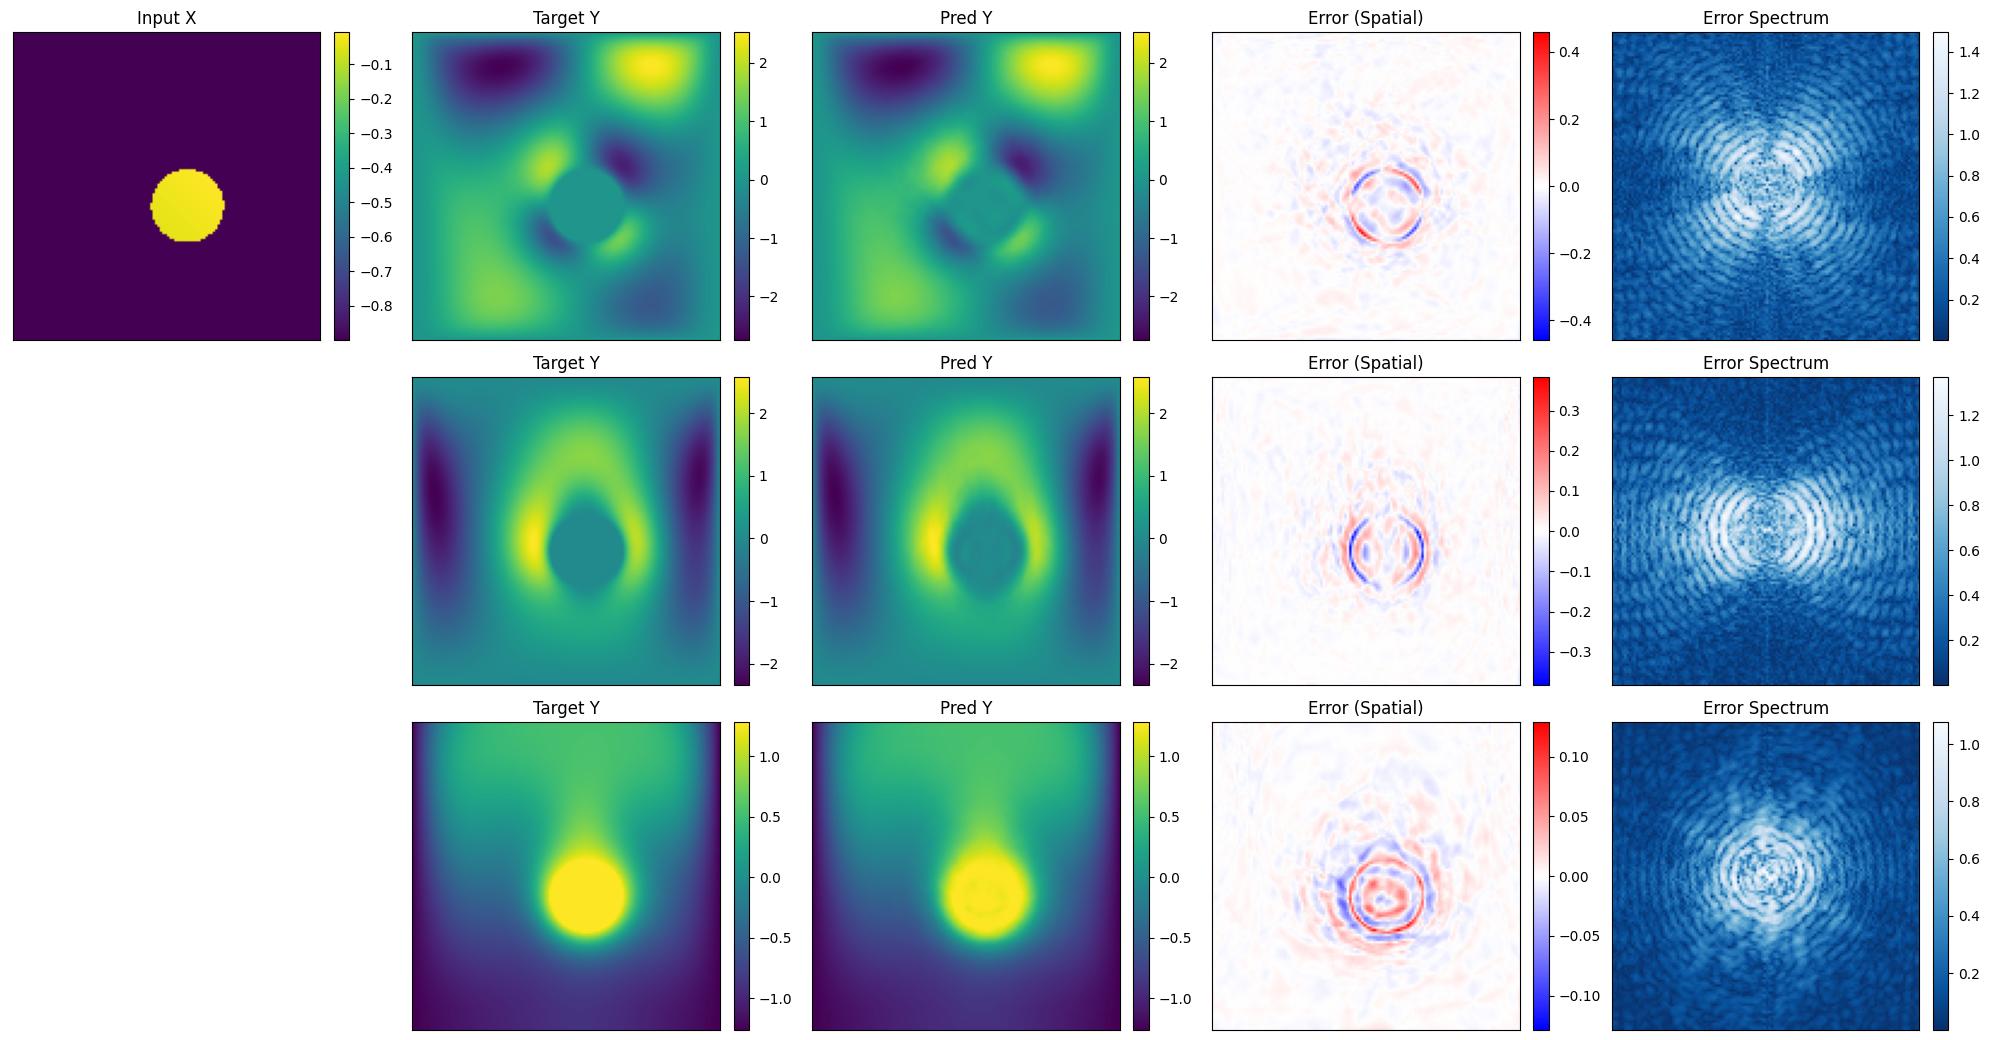

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

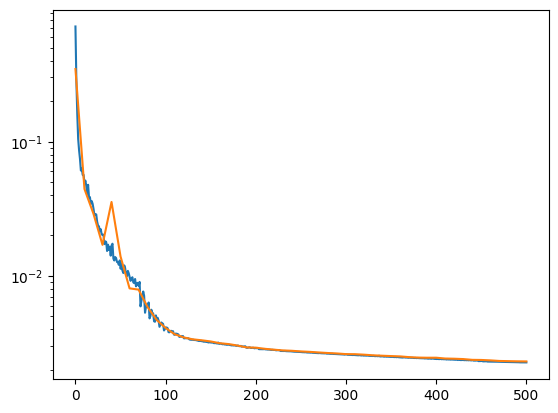

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## TE_Heat

In [ ]:
from utils import MPData
data_name = 'TE_heat'
model_name= 'CDeepONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import MultiTrunkDeepONet
from neuralop.utils import count_model_params
p=256
model = MultiTrunkDeepONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 11,480,512 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 11,480,512


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 4.16/0.17 | loss: 1.61e+00 | test: 1.42e+00 | norm: 0.18
epoch:10 | time: 3.55/0.16 | loss: 3.87e-01 | test: 3.53e-01 | norm: 0.16
epoch:20 | time: 3.78/0.16 | loss: 1.37e-01 | test: 1.37e-01 | norm: 0.11
epoch:30 | time: 3.78/0.16 | loss: 7.78e-02 | test: 6.61e-02 | norm: 0.08
epoch:40 | time: 3.82/0.16 | loss: 3.75e-02 | test: 3.52e-02 | norm: 0.05
epoch:50 | time: 3.83/0.17 | loss: 2.11e-02 | test: 1.69e-02 | norm: 0.03
epoch:60 | time: 3.80/0.16 | loss: 1.06e-02 | test: 9.90e-03 | norm: 0.02
epoch:70 | time: 3.57/0.16 | loss: 1.19e-02 | test: 9.64e-03 | norm: 0.03
epoch:80 | time: 3.97/0.16 | loss: 9.32e-03 | test: 9.55e-03 | norm: 0.03
epoch:90 | time: 3.78/0.16 | loss: 5.79e-03 | test: 4.31e-03 | norm: 0.02
epoch:100 | time: 3.90/0.17 | loss: 3.68e-03 | test: 3.89e-03 | norm: 0.01
epoch:110 | time: 3.57/0.16 | loss: 3.68e-03 | test: 3.94e-03 | norm: 0.01
epoch:120 | time: 3.82/0.17 | loss: 2.61e-03 | test: 2.48e-03 | norm: 0.00
epoch:130 | time: 3.84/0.17 | loss: 

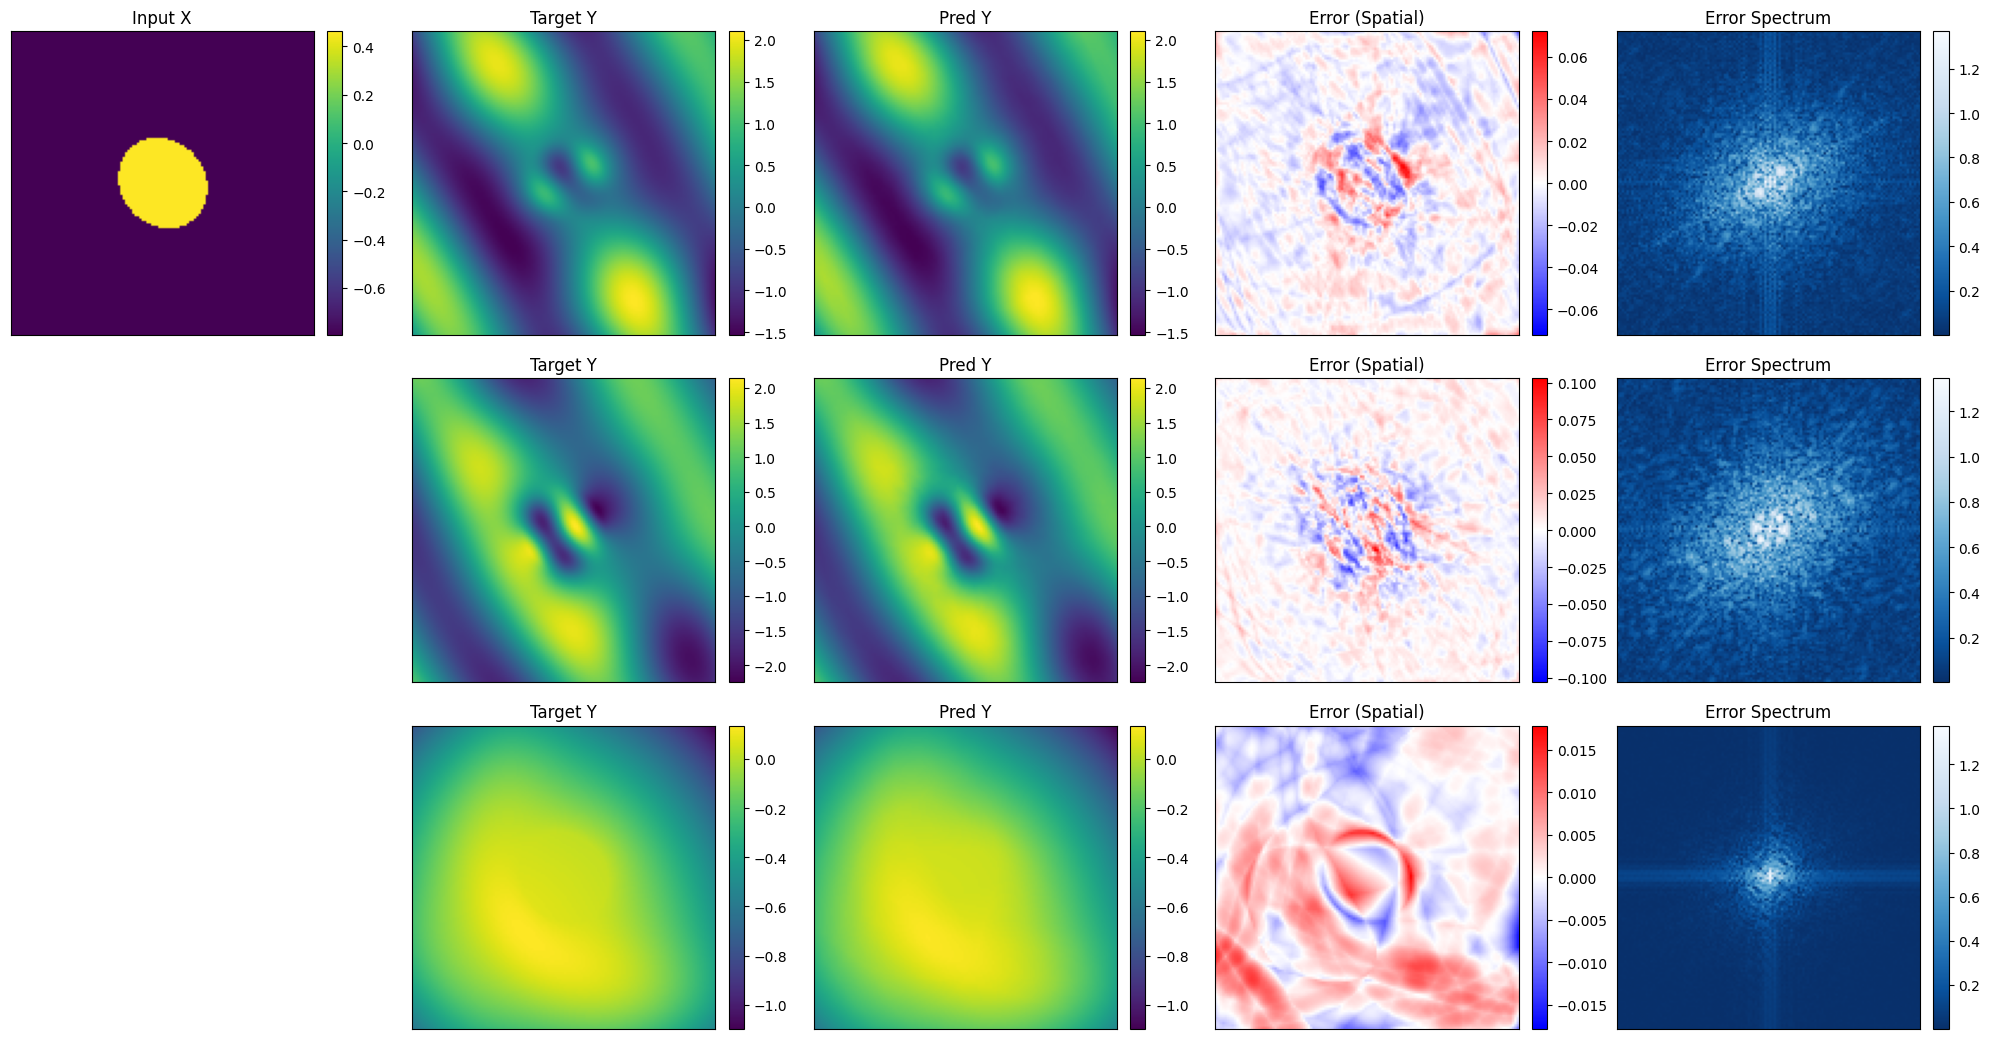

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

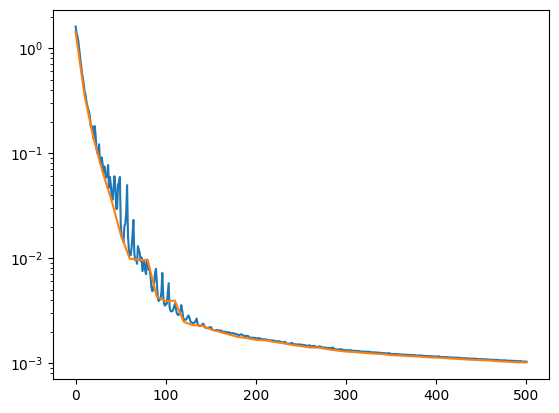

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## E_flow

In [ ]:
from utils import MPData
data_name = 'E_flow'
model_name= 'CDeepONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import MultiTrunkDeepONet
from neuralop.utils import count_model_params
p=256
model = MultiTrunkDeepONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 11,480,512 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 11,480,512


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.98/0.14 | loss: 1.44e+00 | test: 8.56e-01 | norm: 0.30


epoch:10 | time: 4.01/0.14 | loss: 3.37e-01 | test: 3.52e-01 | norm: 0.35


epoch:20 | time: 3.96/0.14 | loss: 2.56e-01 | test: 2.58e-01 | norm: 0.24


epoch:30 | time: 4.00/0.14 | loss: 2.24e-01 | test: 2.21e-01 | norm: 0.15


epoch:40 | time: 3.97/0.14 | loss: 1.99e-01 | test: 1.89e-01 | norm: 0.12


...

epoch:470 | time: 4.00/0.14 | loss: 1.00e-01 | test: 9.99e-02 | norm: 0.02


epoch:480 | time: 3.97/0.14 | loss: 9.99e-02 | test: 9.97e-02 | norm: 0.02


epoch:490 | time: 3.99/0.14 | loss: 9.97e-02 | test: 9.96e-02 | norm: 0.02


epoch:499 | time: 3.96/0.14 | loss: 9.96e-02 | test: 9.95e-02 | norm: 0.02


Finish epoch:499 | train loss: 9.9616e-02 | test loss: 9.9485e-02
total train time : 1990.398
Channel Loss: var0: 2.2552e-04 var1: 4.4648e-02 var2: 5.4611e-02 



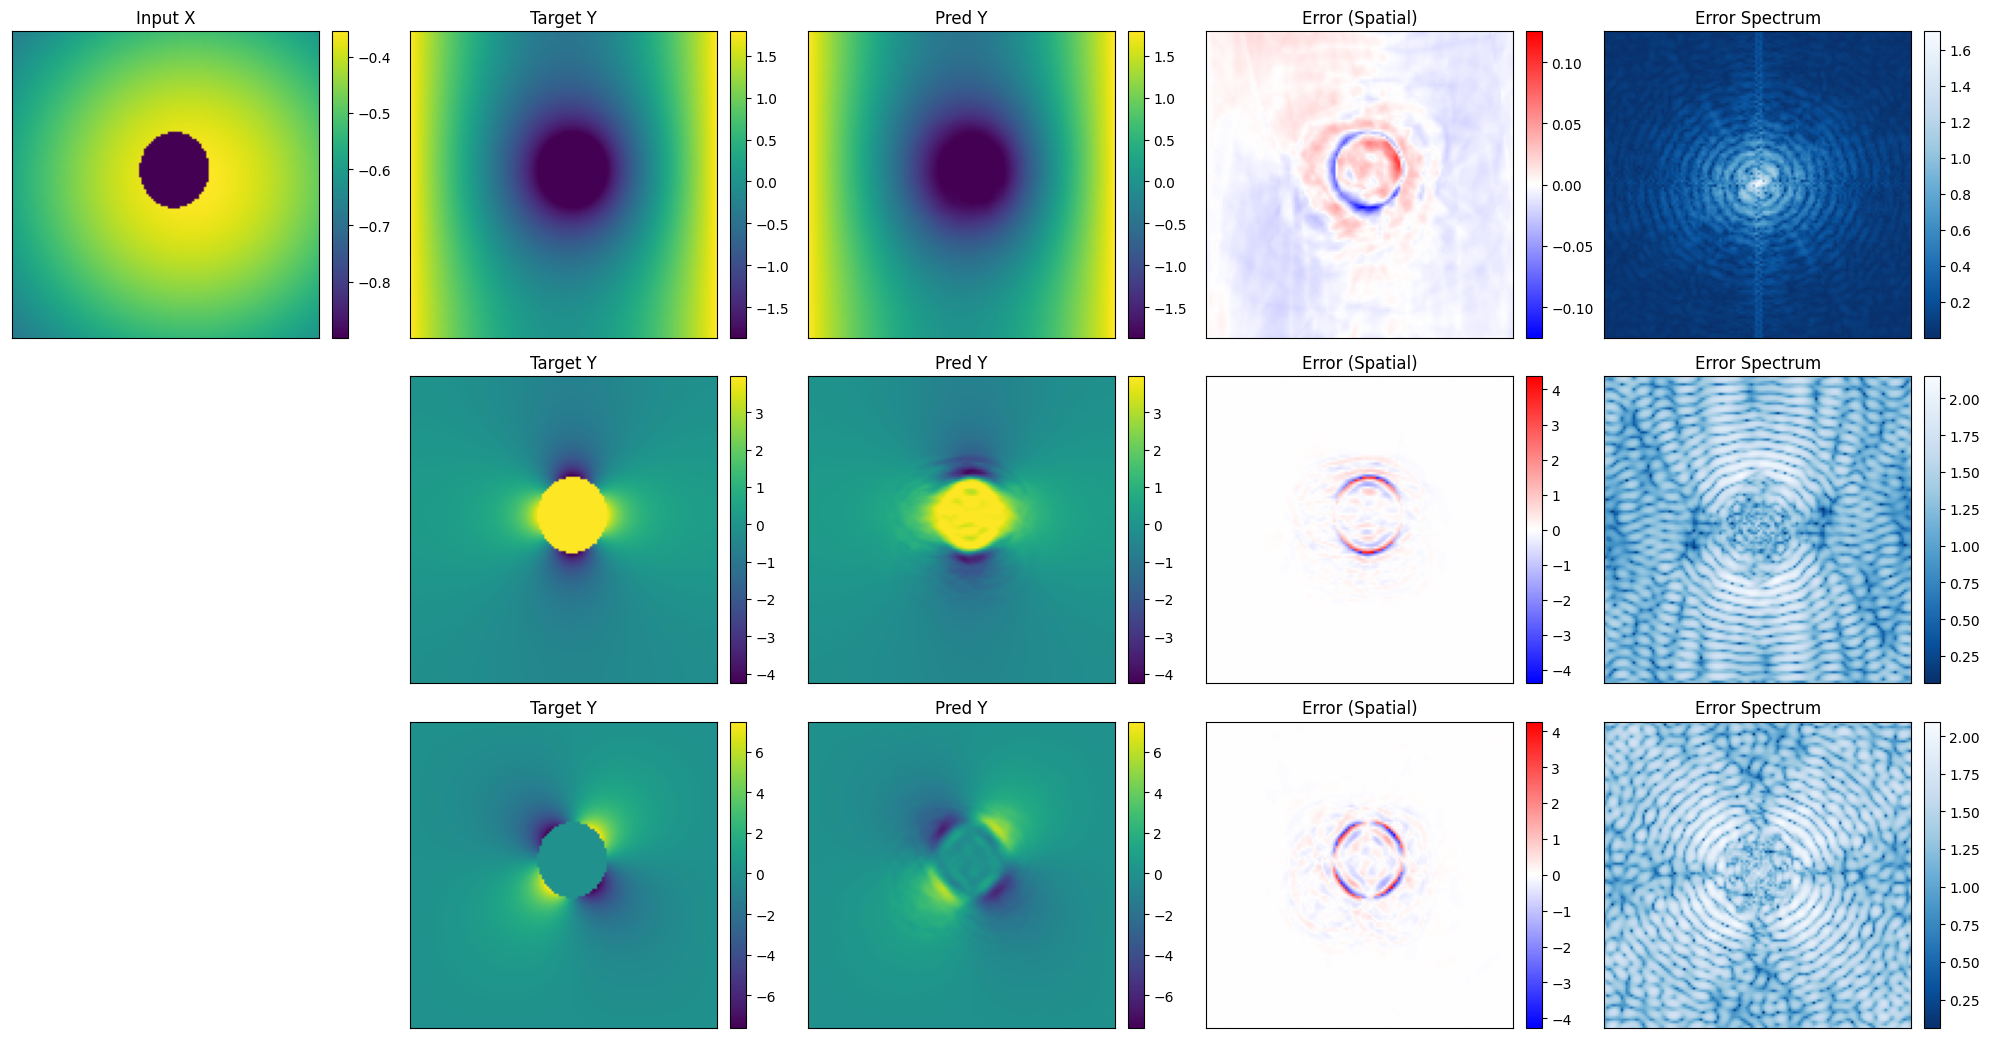

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

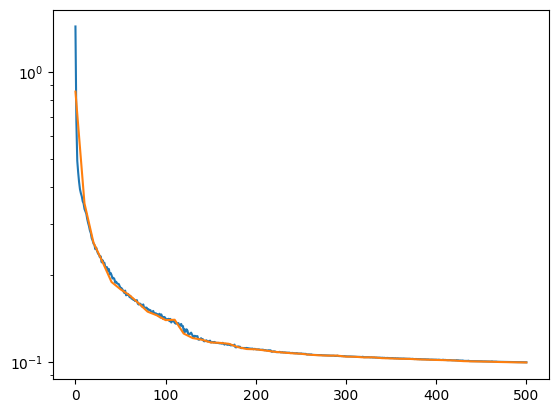

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## MHD

In [ ]:
from utils import MPData
data_name = 'MHD'
model_name= 'CDeepONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.DeepONet import MultiTrunkDeepONet
from neuralop.utils import count_model_params
p=2048
model = MultiTrunkDeepONet(p=p, out_channels=5).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")


Our model has 26,313,152 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}')

total number of parameters: 26,313,152


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 10.93/0.45 | loss: 2.22e+00 | test: 1.37e+00 | norm: 0.64


epoch:10 | time: 10.97/0.45 | loss: 8.98e-01 | test: 8.76e-01 | norm: 2.07


epoch:20 | time: 10.71/0.45 | loss: 8.37e-01 | test: 8.31e-01 | norm: 1.57


epoch:30 | time: 10.89/0.44 | loss: 8.24e-01 | test: 8.28e-01 | norm: 0.92


epoch:40 | time: 10.84/0.41 | loss: 8.20e-01 | test: 8.19e-01 | norm: 1.05


...

epoch:480 | time: 10.51/0.45 | loss: 8.11e-01 | test: 8.15e-01 | norm: 0.04


epoch:490 | time: 12.08/0.44 | loss: 8.11e-01 | test: 8.15e-01 | norm: 0.04


epoch:499 | time: 12.04/0.43 | loss: 8.11e-01 | test: 8.15e-01 | norm: 0.04


Finish epoch:499 | train loss: 8.1130e-01 | test loss: 8.1513e-01
total train time : 5372.340


Channel Loss: var0: 5.0470e-04 var1: 6.6707e-04 var2: 8.1376e-01 var3: 4.8133e-05 var4: 1.5252e-04 



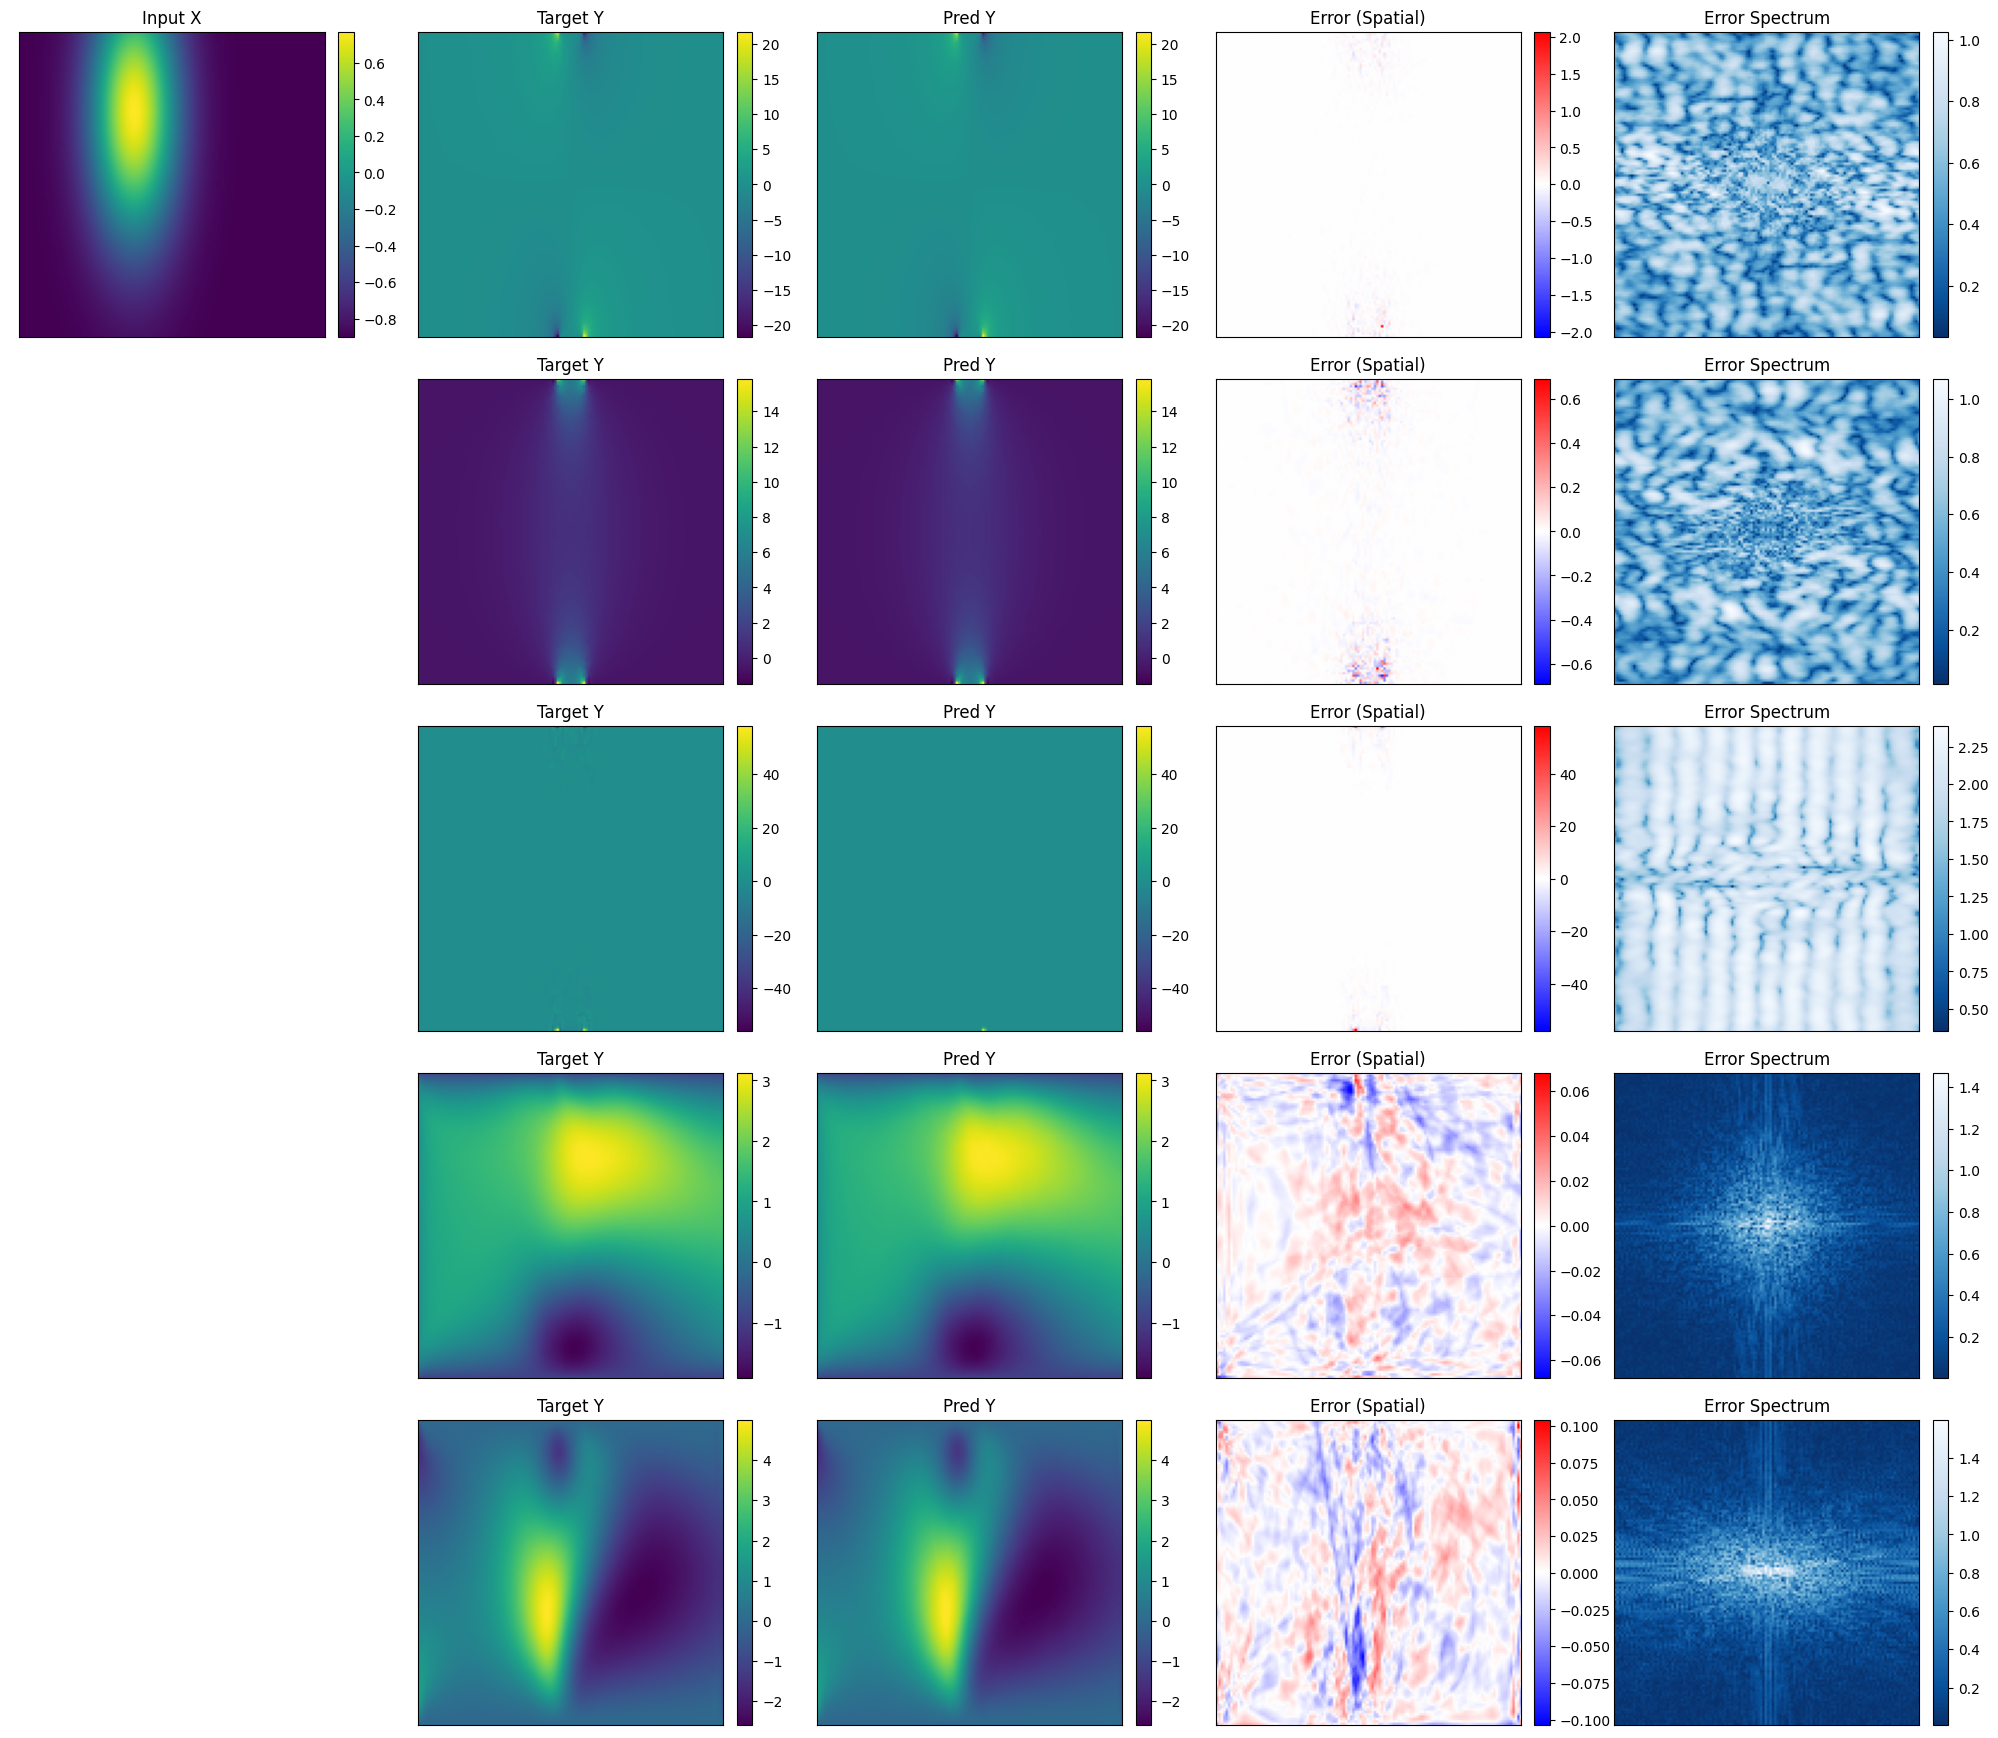

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=5)

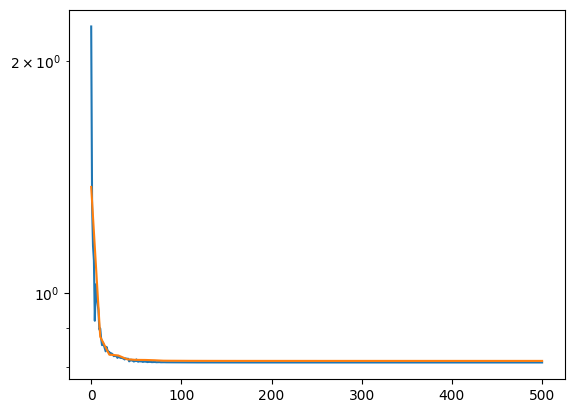

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')